TMZ dosing schedule
  Cycle 1: days 600 – 604  (5 doses × 297.5 mg)
  Cycle 2: days 628 – 632  (5 doses × 297.5 mg)
  Cycle 3: days 656 – 660  (5 doses × 297.5 mg)
  Cycle 4: days 684 – 688  (5 doses × 297.5 mg)
  Cycle 5: days 712 – 716  (5 doses × 297.5 mg)
  Cycle 6: days 740 – 744  (5 doses × 297.5 mg)

Total doses: 30
Dose per day: 297.5 mg  (175 mg/m² × 1.7 m²)

=== Key clinical events ===
  Genesis       day=    0.0  total=1.000e+00  PS=1.00e+00  PR=0.00e+00  CR=0.00e+00
  Detection     day=  600.0  total=1.882e+10  PS=1.49e+10  PR=2.93e+02  CR=3.94e+09

=== PK peak values per cycle ===
  Cycle 1: peak C_plasma=8.260 µg/mL  C_CSF=2.6166 µg/mL  C_CSF=13.48 µM  k_kill=0.6693
  Cycle 2: peak C_plasma=8.260 µg/mL  C_CSF=2.6166 µg/mL  C_CSF=13.48 µM  k_kill=0.6693
  Cycle 3: peak C_plasma=8.260 µg/mL  C_CSF=2.6166 µg/mL  C_CSF=13.48 µM  k_kill=0.6693
  Cycle 4: peak C_plasma=8.260 µg/mL  C_CSF=2.6166 µg/mL  C_CSF=13.48 µM  k_kill=0.6693
  Cycle 5: peak C_plasma=8.260 µg/mL  C_CSF=2.6

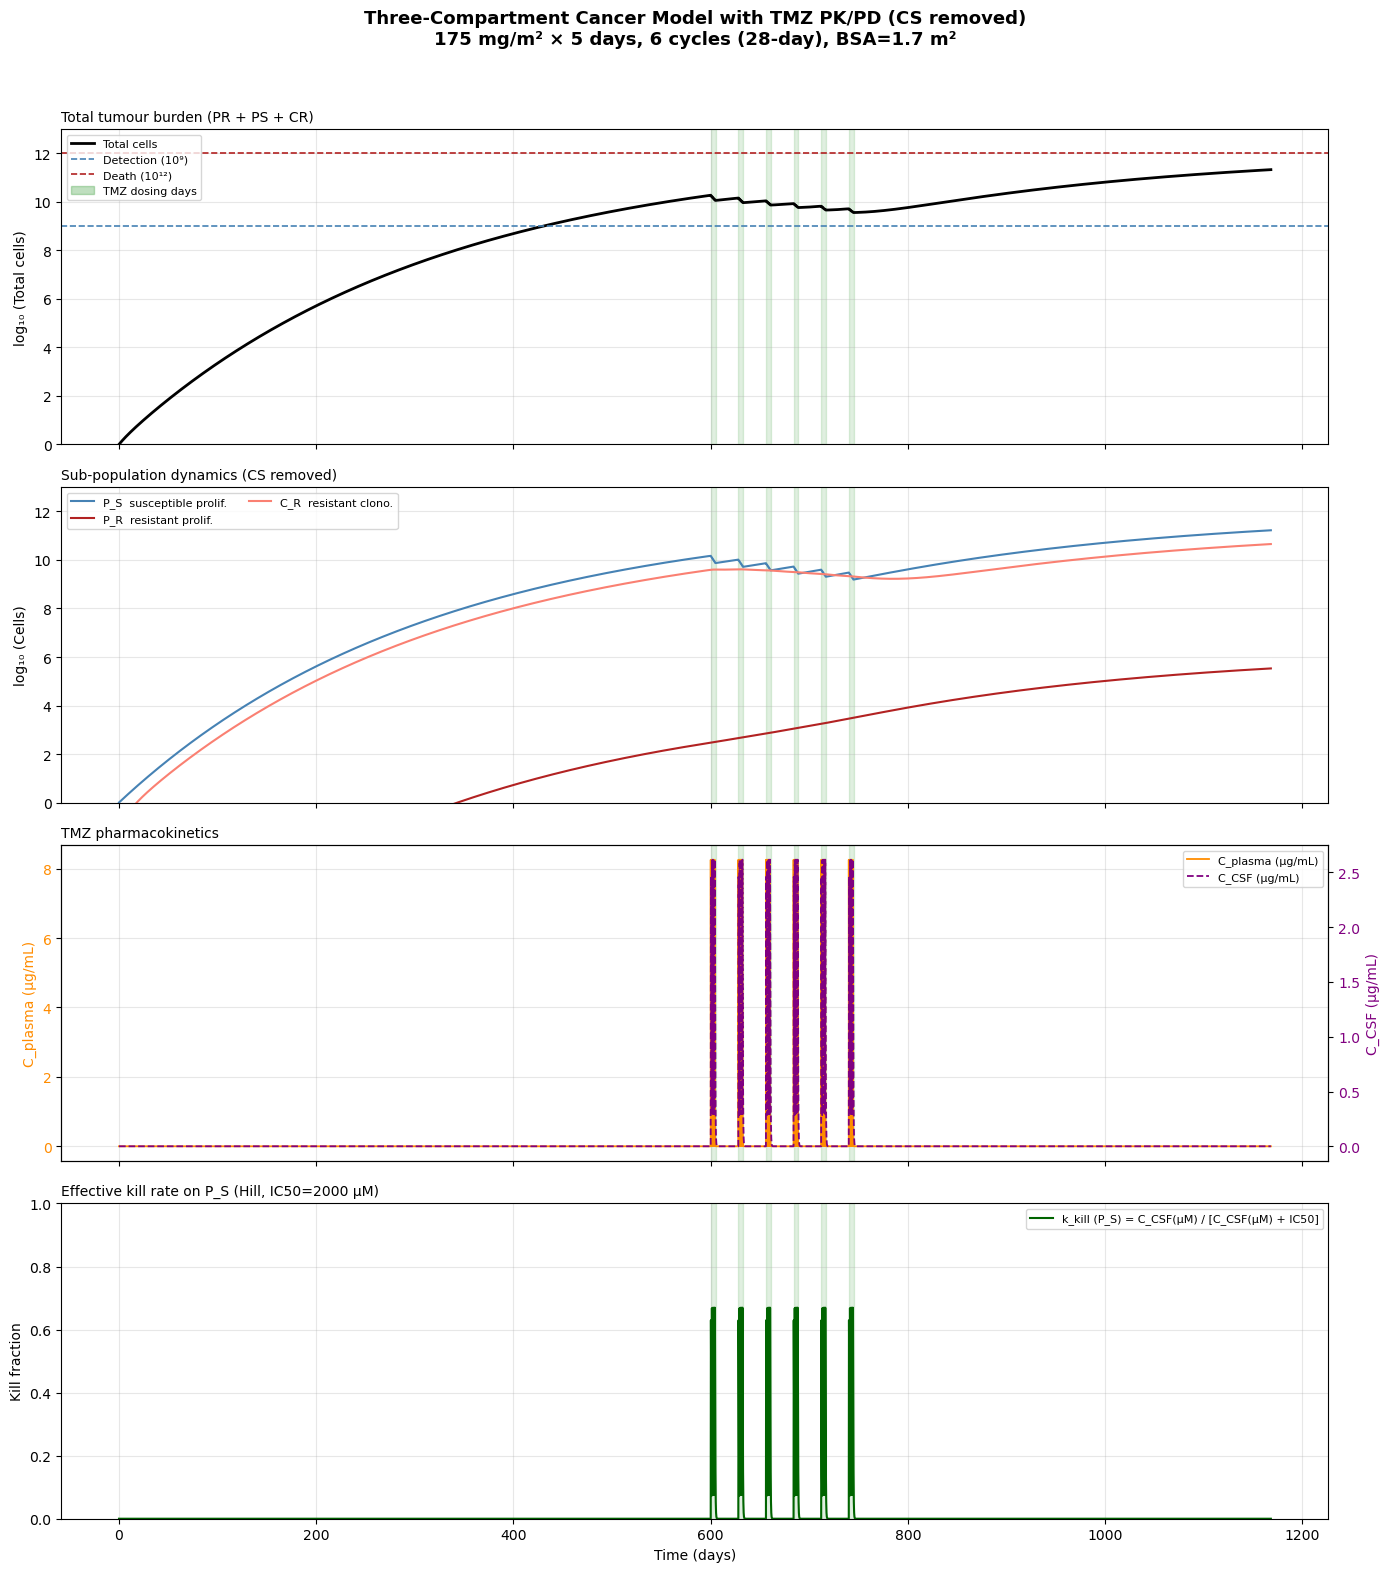


Done.


In [2]:
"""
Three-Compartment Cancer Evolution Model with TMZ PK/PD
=======================================================
Adapted from Westman et al. (2001) — CS (Clonogenic Sensitive) compartment removed.

Integrates:
  - Three-compartment cancer ODE system: PR, PS, CR only
  - Three-compartment TMZ pharmacokinetics: GI → Plasma → CSF
  - Hill-function kill rate based on CSF concentration (IC50 = 2000 µM)
  - Adjuvant TMZ dosing: 6 cycles × 5 days on / 23 days off, 28-day cycle
    Dose = 175 mg/m² × 1.7 m² (typical BSA) = 297.5 mg per dose day

State vector (6 ODEs):
  y[0] = A1   GI tract amount     (mg)
  y[1] = A2   Plasma amount       (mg)
  y[2] = A3   CSF amount          (mg)
  y[3] = PR   Proliferating Resistant cells
  y[4] = PS   Proliferating Sensitive cells
  y[5] = CR   Clonogenic Resistant cells
"""

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ============================================================
# PK Parameters  (all rates in h⁻¹, volumes in L)
# ============================================================
PK = {
    "Ka":  5.8,          # h⁻¹   absorption rate constant
    "CL":  10.0,         # L/h   oral clearance
    "VD":  30.3,         # L     volume of distribution (plasma, oral)
    "Vp":  0.14,         # L     volume of distribution (CSF)
    "k23": 7.2e-4,       # h⁻¹   plasma → CSF transfer
    "k32": 0.14,         # h⁻¹   CSF → plasma transfer
}
# Derived
PK["ke"] = PK["CL"] / PK["VD"]   # h⁻¹  elimination rate from plasma

# ============================================================
# PD / kill Parameters
# ============================================================
IC50_uM    = 2000.0        # µM  (IC50 for TMZ on sensitive cells)
MW_TMZ     = 194.15        # g/mol  (molecular weight of temozolomide)

# ============================================================
# Tumour Biology Parameters  (Table 1, Westman et al. 2001)
# CS terms removed; mu_PR_CS and alpha_S → CR only via PS pathway removed
# ============================================================
BIO = {
    "lam":      0.00396,   # day⁻¹   Gompertzian growth rate
    "K":        5e14,      # cells   carrying capacity
    "alpha_R":  0.20,      # prolif → clono migration (resistant): PR → CR
    "alpha_S":  0.20,      # prolif → clono migration (sensitive): PS → CR (redirected from CS)
    "beta_R":   1e-10,     # day⁻¹   natural back-migration (resistant): CR → PR
    "delta_PR": 0.01925,   # day⁻¹   natural loss, PR
    "delta_PS": 0.01925,   # day⁻¹   natural loss, PS
    "delta_CR": 0.017325,  # day⁻¹   natural loss, CR
    "mu_PS_PR": 1e-10,     # intrinsic resistance gain (PS→PR)
    "mu_PR_PS": 1e-10,     # resistance loss (PR→PS)
    "mu_PS_CR": 1e-11,     # cross-compartment: PS→CR (was mu_PS_CS, now folded into CR)
    # Clinical thresholds
    "N_detect": 1e9,
    "N_death":  1e12,
}


# ============================================================
# Dosing schedule
# ============================================================
DOSE_MG       = 175.0 * 1.7      # mg per dose day
N_CYCLES      = 6
DAYS_ON       = 5
CYCLE_LEN     = 28
T_TREAT_START = 600.0             # day on which treatment begins

def build_dose_schedule(t_start=T_TREAT_START, n_cycles=N_CYCLES,
                        days_on=DAYS_ON, cycle_len=CYCLE_LEN):
    schedule = []
    for c in range(n_cycles):
        cycle_start = t_start + c * cycle_len
        for d in range(days_on):
            schedule.append(cycle_start + d)
    return schedule


# ============================================================
# Gompertzian growth rate  g(PR, PS, CR)
# ============================================================
def g_func(PR, PS, CR, lam, K):
    total = max(PR + PS + CR, 1.0)
    return lam * np.log(K / total)


def A2_to_Cplasma(A2, VD_L):
    return max(A2, 0.0) / VD_L

def A3_to_CCSF(A3, Vp_L):
    return max(A3, 0.0) / Vp_L

def CCSF_to_uM(C_csf_ugmL):
    return C_csf_ugmL * (1000.0 / MW_TMZ)

def hill_kill(C_uM, IC50):
    return C_uM / (C_uM + IC50)


# Combined ODE system  (6 equations, time in HOURS)

def make_combined_odes(bio, pk, ic50):
    lam_h  = bio["lam"]   / 24.0
    dPR_h  = bio["delta_PR"] / 24.0
    dPS_h  = bio["delta_PS"] / 24.0
    dCR_h  = bio["delta_CR"] / 24.0
    bR_h   = bio["beta_R"]   / 24.0

    aR = bio["alpha_R"]; aS = bio["alpha_S"]
    mu_PS_PR = bio["mu_PS_PR"]; mu_PR_PS = bio["mu_PR_PS"]
    mu_PS_CR = bio["mu_PS_CR"]
    # mu_PR_CS removed (no CS compartment)

    Ka  = pk["Ka"];  ke  = pk["ke"]
    k23 = pk["k23"]; k32 = pk["k32"]
    VD  = pk["VD"];  Vp  = pk["Vp"]

    def rhs(t_h, y):
        A1, A2, A3, PR, PS, CR = y
        A1 = max(A1, 0.0); A2 = max(A2, 0.0); A3 = max(A3, 0.0)
        PR = max(PR, 0.0); PS = max(PS, 0.0); CR = max(CR, 0.0)

        # ---- PK (3-compartment oral) ----
        dA1 = -Ka * A1
        dA2 =  Ka * A1 - ke * A2 - k23 * A2 + k32 * A3
        dA3 =  k23 * A2 - k32 * A3

        # ---- Concentrations ----
        Cplasma = A2_to_Cplasma(A2, VD)
        Ccsf    = A3_to_CCSF(A3, Vp)
        C_uM    = CCSF_to_uM(Ccsf)

        # Kill rate (only PS is sensitive to TMZ)
        k_kill_PS = hill_kill(C_uM, ic50)
        k_kill_PR = 0.0
        k_kill_CR = 0.0

        # ---- Gompertzian growth (h⁻¹) — no CS ----
        gPC = g_func(PR, PS, CR, lam_h, bio["K"])

        # ---- Cell ODEs ----
        # dP_R/dt
        dPR = (
            ((1 - aR - mu_PR_PS) * PR + mu_PS_PR * PS) * gPC
            + bR_h * CR
            - dPR_h * PR
            - k_kill_PR * Cplasma * PR
        )

        # dP_S/dt

        dPS = (
            ((1 - aS - mu_PS_CR - mu_PS_PR) * PS + mu_PR_PS * PR) * gPC
            - dPS_h * PS
            - k_kill_PS * Ccsf * PS
            + bR_h*mu_PR_PS*CR
        )
    
        dCR = (
            aR * PR * gPC
            + aS * PS * gPC          
            + mu_PS_CR * PS * gPC
            - bR_h * CR
            - dCR_h * CR
            - k_kill_CR * Ccsf * CR
            + bR_h*mu_PR_PS*CR
        )

        return [dA1, dA2, dA3, dPR, dPS, dCR]

    return rhs


# ============================================================
# Simulation engine
# ============================================================
def run_simulation(bio, pk, dose_schedule_days, t_end_days=800,
                   bsa_m2=1.7, dose_mgm2=175.0):
    dose_mg = dose_mgm2 * bsa_m2
    rhs = make_combined_odes(bio, pk, IC50_uM)

    # Initial state: one susceptible proliferating cell, no drug
    # y = [A1, A2, A3, PR, PS, CR]
    y0 = np.array([0.0, 0.0, 0.0,
                   0.0, 1.0, 0.0],
                  dtype=float)

    t_end_h = t_end_days * 24.0
    dose_times_h = sorted([d * 24.0 for d in dose_schedule_days])
    breakpoints_h = np.unique(np.concatenate([[0.0], dose_times_h, [t_end_h]]))

    t_list = []; y_list = []
    events = [("Genesis", 0.0)]
    state  = y0.copy()
    detected = False; death_recorded = False

    for k in range(len(breakpoints_h) - 1):
        t0_h = breakpoints_h[k]
        t1_h = breakpoints_h[k + 1]
        if t1_h <= t0_h:
            continue

        n_pts = max(int((t1_h - t0_h) / 0.5), 5)
        t_eval_h = np.linspace(t0_h, t1_h, n_pts)

        sol = solve_ivp(
            rhs, [t0_h, t1_h], state,
            t_eval=t_eval_h,
            method="RK45",
            rtol=1e-7, atol=1e-10,
        )

        t_list.append(sol.t)
        y_list.append(sol.y)
        state = np.maximum(sol.y[:, -1], 0.0)

        # Clinical milestone checks
        cells_total = state[3:].sum()   # PR + PS + CR

        if not detected and cells_total >= bio["N_detect"]:
            detected = True
            events.append(("Detection", sol.t[-1] / 24.0))

        if not death_recorded and cells_total >= bio["N_death"]:
            death_recorded = True
            events.append(("Death", sol.t[-1] / 24.0))

        if k + 1 < len(breakpoints_h):
            t_next_h = breakpoints_h[k + 1]
            if t_next_h in dose_times_h:
                state[0] += dose_mg
                cycle_num  = int((t_next_h / 24.0 - dose_schedule_days[0]) // CYCLE_LEN) + 1
                day_in_cyc = int((t_next_h / 24.0 - dose_schedule_days[0]) % CYCLE_LEN) + 1
                events.append((f"Dose C{cycle_num}D{day_in_cyc}", t_next_h / 24.0))

    t_h_arr = np.concatenate(t_list)
    y_arr   = np.hstack(y_list)
    t_days_arr = t_h_arr / 24.0

    Cplasma_arr = np.array([A2_to_Cplasma(a2, pk["VD"]) for a2 in y_arr[1]])
    Ccsf_arr    = np.array([A3_to_CCSF(a3, pk["Vp"])    for a3 in y_arr[2]])
    C_uM_arr    = CCSF_to_uM(Ccsf_arr)
    kill_arr    = 100 * hill_kill(C_uM_arr, IC50_uM)

    pk_out = {
        "Cplasma": Cplasma_arr,
        "Ccsf":    Ccsf_arr,
        "C_uM":    C_uM_arr,
        "k_kill":  kill_arr,
    }

    return t_days_arr, y_arr, pk_out, events


# ============================================================
# Plotting
# ============================================================
def plot_all(t, y, pk_out, events, dose_schedule_days, bio):
    PR = y[3]; PS = y[4]; CR = y[5]
    total = PR + PS + CR

    cycle_spans = []
    for c in range(N_CYCLES):
        t0 = T_TREAT_START + c * CYCLE_LEN
        t1 = t0 + DAYS_ON
        cycle_spans.append((t0, t1))

    fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
    fig.suptitle(
        "Three-Compartment Cancer Model with TMZ PK/PD (CS removed)\n"
        f"175 mg/m² × 5 days, {N_CYCLES} cycles (28-day), BSA=1.7 m²",
        fontsize=13, fontweight="bold"
    )

    def shade_cycles(ax):
        for (t0, t1) in cycle_spans:
            ax.axvspan(t0, t1, alpha=0.12, color="green", label="_nolegend_")

    # ---- Panel 1: Total tumour burden ----
    ax = axes[0]
    safe_total = np.where(total > 0, total, 0.1)
    ax.plot(t, np.log10(safe_total), color="black", lw=2.0, label="Total cells")
    ax.axhline(np.log10(bio["N_detect"]), color="steelblue", ls="--", lw=1.2, label="Detection (10⁹)")
    ax.axhline(np.log10(bio["N_death"]),  color="firebrick",  ls="--", lw=1.2, label="Death (10¹²)")
    shade_cycles(ax)
    ax.set_ylabel("log₁₀ (Total cells)", fontsize=10)
    patch = Patch(color="green", alpha=0.25, label="TMZ dosing days")
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles + [patch], labels + ["TMZ dosing days"], fontsize=8, loc="upper left")
    ax.set_ylim(0, 13)
    ax.grid(True, alpha=0.3)
    ax.set_title("Total tumour burden (PR + PS + CR)", fontsize=10, loc="left")

    # ---- Panel 2: Sub-populations ----
    ax = axes[1]
    for arr, lbl, col in [
        (PS, "P_S  susceptible prolif.", "steelblue"),
        (PR, "P_R  resistant prolif.",   "firebrick"),
        (CR, "C_R  resistant clono.",    "salmon"),
    ]:
        safe = np.where(arr > 0, arr, 0.1)
        ax.plot(t, np.log10(safe), lw=1.5, label=lbl, color=col)
    shade_cycles(ax)
    ax.set_ylabel("log₁₀ (Cells)", fontsize=10)
    ax.legend(fontsize=8, loc="upper left", ncol=2)
    ax.set_ylim(0, 13)
    ax.grid(True, alpha=0.3)
    ax.set_title("Sub-population dynamics (CS removed)", fontsize=10, loc="left")

    # ---- Panel 3: PK ----
    ax = axes[2]
    ax_r = ax.twinx()
    lns1 = ax.plot(t, pk_out["Cplasma"], color="darkorange", lw=1.3, label="C_plasma (µg/mL)")
    lns2 = ax_r.plot(t, pk_out["Ccsf"],  color="purple",     lw=1.3, ls="--", label="C_CSF (µg/mL)")
    shade_cycles(ax)
    ax.set_ylabel("C_plasma (µg/mL)", fontsize=10, color="darkorange")
    ax_r.set_ylabel("C_CSF (µg/mL)", fontsize=10, color="purple")
    ax.tick_params(axis='y', labelcolor="darkorange")
    ax_r.tick_params(axis='y', labelcolor="purple")
    lines = lns1 + lns2
    ax.legend(lines, [l.get_label() for l in lines], fontsize=8, loc="upper right")
    ax.set_title("TMZ pharmacokinetics", fontsize=10, loc="left")
    ax.grid(True, alpha=0.3)

    # ---- Panel 4: Kill rate ----
    ax = axes[3]
    ax.plot(t, pk_out["k_kill"], color="darkgreen", lw=1.5,
            label="k_kill (P_S) = C_CSF(µM) / [C_CSF(µM) + IC50]")
    shade_cycles(ax)
    ax.set_ylabel("Kill fraction", fontsize=10)
    ax.set_xlabel("Time (days)", fontsize=10)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8, loc="upper right")
    ax.grid(True, alpha=0.3)
    ax.set_title("Effective kill rate on P_S (Hill, IC50=2000 µM)", fontsize=10, loc="left")

    plt.tight_layout(rect=[0, 0, 1, 0.96])


# ============================================================
# Entry point
# ============================================================
if __name__ == "__main__":
    dose_days = build_dose_schedule()

    print("=" * 60)
    print("TMZ dosing schedule")
    print("=" * 60)
    for c in range(N_CYCLES):
        start_d = T_TREAT_START + c * CYCLE_LEN
        end_d   = start_d + DAYS_ON - 1
        print(f"  Cycle {c+1}: days {start_d:.0f} – {end_d:.0f}  "
              f"({DAYS_ON} doses × {DOSE_MG:.1f} mg)")

    print(f"\nTotal doses: {len(dose_days)}")
    print(f"Dose per day: {DOSE_MG:.1f} mg  ({175:.0f} mg/m² × 1.7 m²)")

    t, y, pk_out, events = run_simulation(
        BIO, PK, dose_days,
        t_end_days=T_TREAT_START + N_CYCLES * CYCLE_LEN + 400
    )

    print("\n=== Key clinical events ===")
    milestone_events = [(lbl, day) for lbl, day in events
                        if lbl in ("Genesis", "Detection", "Death")]
    for lbl, day in milestone_events:
        idx = np.argmin(np.abs(t - day))
        PR, PS, CR = y[3, idx], y[4, idx], y[5, idx]
        print(f"  {lbl:12s}  day={day:7.1f}  total={PR+PS+CR:.3e}  "
              f"PS={PS:.2e}  PR={PR:.2e}  CR={CR:.2e}")

    print("\n=== PK peak values per cycle ===")
    for c in range(N_CYCLES):
        c_start_day = T_TREAT_START + c * CYCLE_LEN
        c_end_day   = c_start_day + DAYS_ON + 1
        mask = (t >= c_start_day) & (t <= c_end_day)
        if mask.any():
            peak_plasma = pk_out["Cplasma"][mask].max()
            peak_csf    = pk_out["Ccsf"][mask].max()
            peak_kill   = pk_out["k_kill"][mask].max()
            peak_uM     = pk_out["C_uM"][mask].max()
            print(f"  Cycle {c+1}: peak C_plasma={peak_plasma:.3f} µg/mL  "
                  f"C_CSF={peak_csf:.4f} µg/mL  "
                  f"C_CSF={peak_uM:.2f} µM  "
                  f"k_kill={peak_kill:.4f}")

    plot_all(t, y, pk_out, events, dose_days, BIO)
    plt.show()
    print("\nDone.")